## Set up

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import pprint
from scipy.stats import fisher_exact, ttest_ind, ttest_rel, pointbiserialr, pearsonr
from IPython.display import display, HTML
import sys
import analysis_utility_funcs as unified_funcs # ---- this worked because of the new pyproject.toml file, and we ran 'pip install -e .' in the conda env setup script, which runs the pyproject.toml, which basically makes any (root-level) cross-folder imports work without needing to mess with sys.path. So I can import python scripts if I want from src, run_annotation, archive, whichever.
import analysis_ntbk_helpers  # module form, needed to override UTILITY_PICK_STRATEGY later (see that cell)
from analysis_ntbk_helpers import *  # sig_stars, bar_dot_sem, paired_bar_dot_sem, per_scenario_proportion,
                                      # paired_proportion_barplots, create_utility_bar_dot_plots,
                                      # perform_t_tests, intentionality_by_I_label_plot

In [2]:
src_path = Path().resolve() / "../../src"
sys.path.append(src_path)
project_root = src_path.resolve().parent  
sys.path.append(str(project_root))

In [3]:

import src.generic_analysis_utils as generic_analysis_utils

In [4]:
# Automatically reload modules when they change
%load_ext autoreload
%autoreload 2


helper code in [`analysis_ntbk_helpers.py`](./analysis_ntbk_helpers.py) 

## Load the Annotated Franken dataset as a dataframe.


### condition descriptions:
- Scenarios have two intensities : mild ("mild_harm_mild_good") and severe ("severe_harm_very_good")
- Within each, 8 causal conditions : CC/COC (i.e. means/side-effect) x In/Evitability x Action/Prevention (i.e. commission/omission)
- 8 Each causal condition contains 10 annotated scenarios, SID index them from 0-9 within each condition
-  Therefore, we get 80 mild and 80 severe scenarios totalling 160 annotated scenarios.
- The annotator generates multiple outcome events for each scenarios, each event gets its own row. So total row count is 800+.

In [5]:
all_FRANKEN_df = []

intensities = ["mild_harm_mild_good", "severe_harm_very_good"]
causal_conditions = ["cc_evitable_action_yes_stories", "cc_evitable_prevention_no_stories", "cc_inevitable_action_yes_stories", "cc_inevitable_prevention_no_stories", "coc_evitable_action_yes_stories", "coc_evitable_prevention_no_stories", "coc_inevitable_action_yes_stories", "coc_inevitable_prevention_no_stories"]

for intensity in intensities:
    for causal_condition in causal_conditions:
        df = unified_funcs.read_all_scenarios(f"../../scenarios_inputs/franken/conditions_{intensity}/{causal_condition}.json", f"../../annotated_outputs/franken_o1o2/conditions_{intensity}/{causal_condition}/")
        all_FRANKEN_df.append(df)
        # SPECIAL - add the intensity and causal_condition as columns to the dataframe
        all_FRANKEN_df[-1]["intensity"] = intensity
        all_FRANKEN_df[-1]["causal_condition"] = causal_condition
all_FRANKEN_df = pd.concat(all_FRANKEN_df, ignore_index=True)
# sort the intensity column by the order of the intensities in the intensities list above
all_FRANKEN_df["intensity"] = pd.Categorical(all_FRANKEN_df["intensity"], categories=intensities, ordered=True)
# sort them by the order of the causal conditions in the causal_conditions list above
all_FRANKEN_df["causal_condition"] = pd.Categorical(all_FRANKEN_df["causal_condition"], categories=causal_conditions, ordered=True)
# sort the dataframe by intensity, then by causal condition, then by SID, then by option --- this is how I think is best to sort it for readability but can be changed up.
all_FRANKEN_df = all_FRANKEN_df.sort_values(by=["intensity","causal_condition", "SID", "option"]).reset_index(drop=True)
# drop all the rows where SID is greater than 9
all_FRANKEN_df = all_FRANKEN_df[all_FRANKEN_df["SID"] <= 9]
display(HTML(all_FRANKEN_df[0:5].to_html()))
print("number of rows in all_FRANKEN_df:", len(all_FRANKEN_df))

,SID,option,event,being,C,I,K,utility,deontic,intensity,causal_condition
0,0,1: renovate the park.,The park closes temporarily,i,+,+,+,"{'residents of the community who use or value the park': '-55', 'i': '0'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
1,0,1: renovate the park.,Residents lose access to the recreational space during the renovation,i,+,+,+,"{'residents of the community who use or value the park': '-68', 'i': '0'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
2,0,1: renovate the park.,Residents experience inconvenience,i,+,-,+,"{'residents of the community who use or value the park': '-35', 'i': '0'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
3,0,1: renovate the park.,Residents experience disappointment,i,+,-,+,"{'residents of the community who use or value the park': '-55', 'i': '-12'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
4,0,1: renovate the park.,Park facilities are improved,i,+,+,+,"{'residents of the community who use or value the park': '84', 'i': '12'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories


number of rows in all_FRANKEN_df: 754


In [6]:
all_FRANKEN_df["evitability"] = all_FRANKEN_df["causal_condition"].apply(lambda x: "evitable" if "_evitable_" in x else "inevitable" if "_inevitable_" in x else "unknown")

all_FRANKEN_df["means_vs_sideeffect"] = all_FRANKEN_df["causal_condition"].apply(lambda x: "means" if "cc_" in x else "sideeffect" if "coc_" in x else "unknown")

In [7]:
#convert + and -'s into 1's and 0's fcor C I and K columns


all_FRANKEN_df["C"] = all_FRANKEN_df["C"].apply(lambda x: 1 if x == "+" else 0)
all_FRANKEN_df["I"] = all_FRANKEN_df["I"].apply(lambda x: 1 if x == "+" else 0)
all_FRANKEN_df["K"] = all_FRANKEN_df["K"].apply(lambda x: 1 if x == "+" else 0)

# Analysis 4 -- Do "severe" scenarios get events with more extreme utility scores than "mild" scenarios?
### Comparing the utility score distributions between mild and severe counterparts of each causal condition (also checking overall)
### **Commonsense hypothesis =** The "severe_harm_very_good" utility distributions SHOULD be more negative (on the harm side) AND more positive (on the good side) overall than the "mild_harm_mild_good" utility distributions.

#### **How do we pick one utility score to represent a scenario?**
##### A scenario has several generated events, and each event has its own utility score per identified entity (agent + any bystanders/patients). Reducing all of that down to one number per scenario is two independent choices:

1. ##### **Which entities count** -- the `UTILITY_PICK_STRATEGY` flag in the next cell:
    - ##### **`simplest`** -- everyone (the agent "i" and every other identified entity)
    - ##### **`i_only`** -- just the agent "i"
    - ##### **`non_i_only`** -- everyone except "i", i.e. all patients/bystanders, undifferentiated

2. ##### **How to reduce the pool to one number** -- `UTILITY_AGG_FUNC` in the next cell. Every value from every entity selected above, across every event of the scenario, is pooled into one flat list first (entities are never treated specially relative to each other or to other events once step 1 has picked which ones count) -- then that pool is reduced with:
    - ##### **`min`** -- most-negative value in the pool ("primary harm" magnitude -- peak severity)
    - ##### **`max`** -- most-positive value in the pool ("primary good" magnitude -- peak severity)
    - ##### **`np.mean`** -- average across everything in the pool (overall/average tone, rather than the single worst/best moment)

##### Change both flags in the next cell.

In [170]:
# Two independent choices for turning a scenario's per-event, per-entity utility scores into one
# number (see markdown above): which entities count (UTILITY_PICK_STRATEGY), and how the resulting
# pool of values gets reduced to a single number (UTILITY_AGG_FUNC). Both are used by every
# downstream analysis that calls _reduce_to_per_scenario (Analysis 4 only, now that 5B is gone).

# "simplest"    -- everyone (agent + bystanders)
# "i_only"      -- just the agent "i"
# "non_i_only"  -- everyone except "i" (all patients/bystanders, undifferentiated)
analysis_ntbk_helpers.UTILITY_PICK_STRATEGY = "non_i_only"

# min      -- most-negative pooled value (peak harm severity -- pair with alternative="less" below)
# max      -- most-positive pooled value (peak good severity -- pair with alternative="greater" below)
# np.mean  -- average across the whole pool (overall tone, not just the peak)
UTILITY_AGG_FUNC = np.mean

# THIS WILL AFFECT ANALYSIS 4 ONLY.

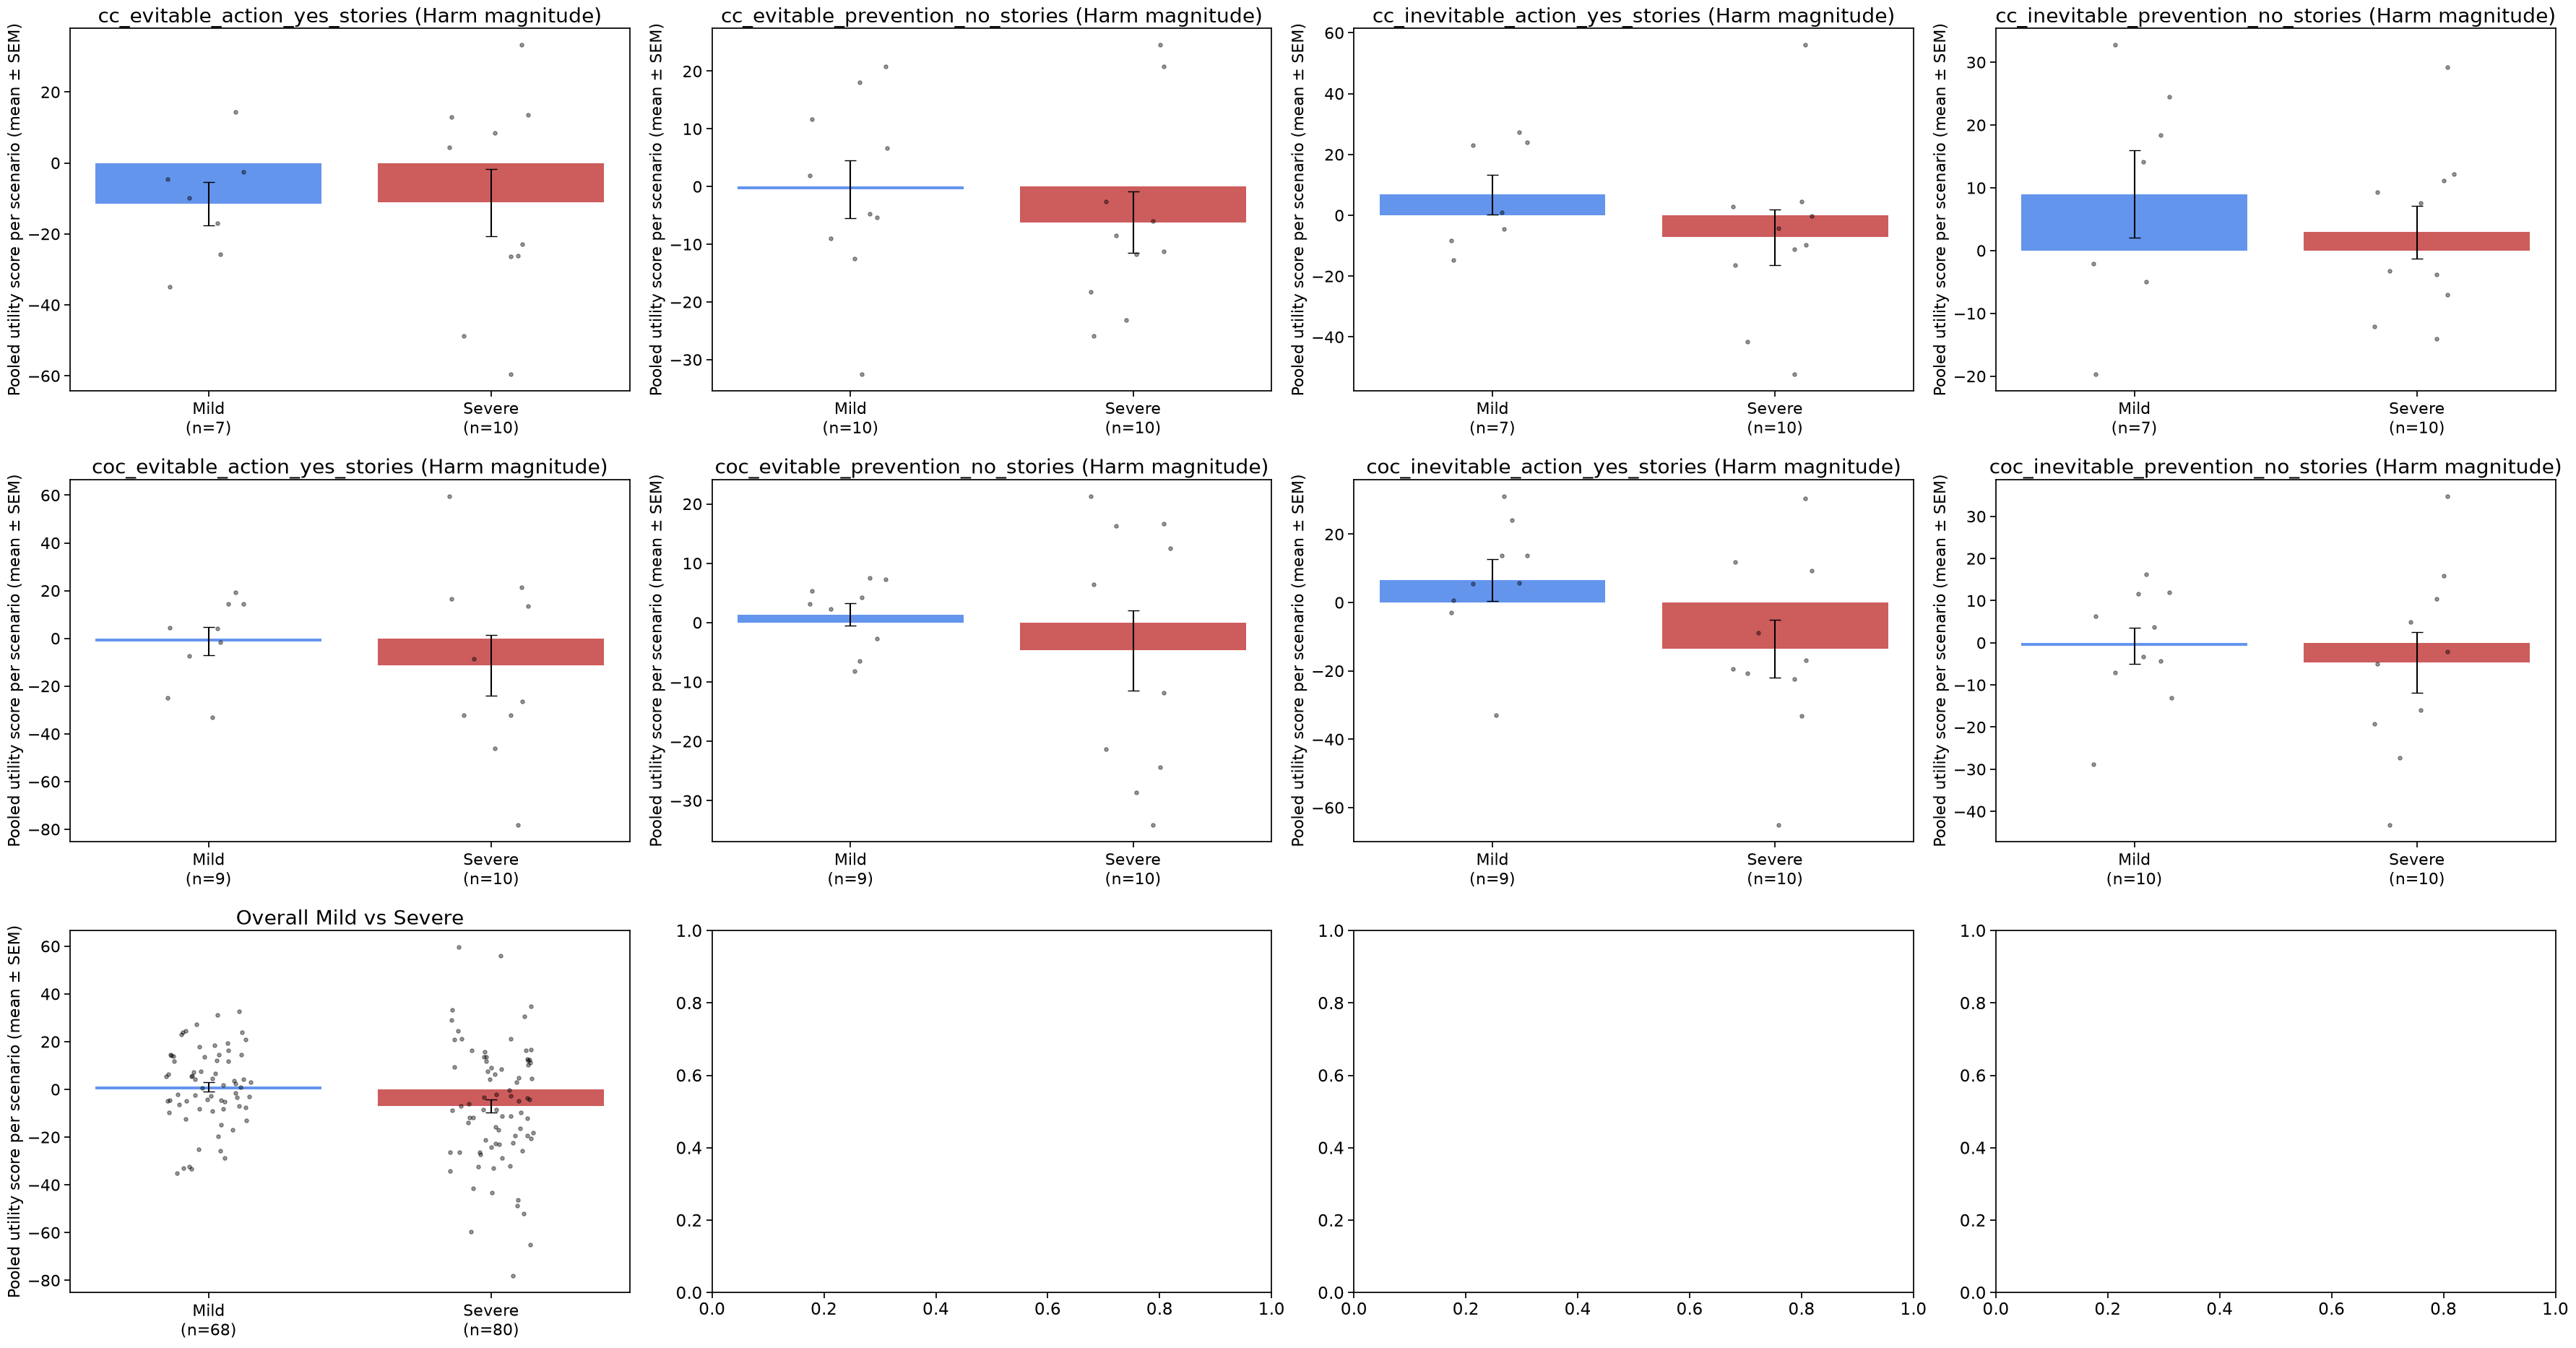

In [171]:
create_utility_bar_dot_plots(all_FRANKEN_df, "(Harm magnitude)", UTILITY_AGG_FUNC, "Pooled utility score per scenario (mean ± SEM)")

### **RESULT:**

- ### The utility scores look more negative-shifted in general for severe scenarios in general.

- ### This tell us that the "severe" scenarios' worst scores are more negative than "mild" scenarios' worst scores. (So "severe_harm" is indeed more severe than "mild_harm"). 

- ### Is "_very_good" indeed more good than "_mild_good" though? We don't know that part. We could know if we compared the most positive event utility scores b/w severe and mild scenarios instead (which would be the opposite of a primary harm), but it doesn't really matter as a thing to check. I suspect it is true.

### Is the severe utility distribution **statistically significantly** more negative (harm) than the mild distribution? One-sided t-tests across the 9 tests (8 causal conditions + overall) within each of the two utility directions:

In [ ]:
print("Harm magnitude (pooled utility, UTILITY_AGG_FUNC applied): one-sided test that severe < mild, across 9 tests:")
harm_t_test_results = perform_t_tests(all_FRANKEN_df, UTILITY_AGG_FUNC, alternative="less")
pprint.pprint(harm_t_test_results)

### Note: t-stat being negative means that severe scores are indeed more negative than mild.

### **RESULT:** The severe utility score distributions are (basically) always statistically significantly more negative than mild counterpart -- there is a consistent diference in utility score distribution between severe and mild scenarios

### **RESULT (corrected):** Annotator I+/- labelling on the qualitatively-picked primary harm event now DOES correlate significantly with human intentionality overall (r=0.32, p=0.003).